In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

In [2]:
from google.colab import files
uploaded=files.upload()

Saving transactions.csv to transactions.csv


In [3]:
df=pd.read_csv('/content/transactions.csv')

In [4]:
df.head()



,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,0,1,1,1,2024-01-06T04:09:39Z,370.95,0
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,2024-01-09T20:13:47Z,149.62,0
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,2024-01-12T06:20:11Z,164.08,0
3,4,1,141,47,147.93,112.47,FR,FR,web,fashion,0,1,1,1,2024-01-15T17:00:04Z,397.40,0
4,5,1,141,47,147.93,132.91,FR,US,web,electronics,0,1,1,1,2024-01-17T01:27:31Z,935.28,0


In [5]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299695 entries, 0 to 299694
Data columns (total 17 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   transaction_id           299695 non-null  int64  
 1   user_id                  299695 non-null  int64  
 2   account_age_days         299695 non-null  int64  
 3   total_transactions_user  299695 non-null  int64  
 4   avg_amount_user          299695 non-null  float64
 5   amount                   299695 non-null  float64
 6   country                  299695 non-null  object 
 7   bin_country              299695 non-null  object 
 8   channel                  299695 non-null  object 
 9   merchant_category        299695 non-null  object 
 10  promo_used               299695 non-null  int64  
 11  avs_match                299695 non-null  int64  
 12  cvv_result               299695 non-null  int64  
 13  three_ds_flag            299695 non-null  int64  
 14  tran

,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,is_fraud
count,299695.0000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000
mean,149848.0000,3002.559432,973.397871,50.673321,148.142973,177.165279,0.153640,0.837999,0.872110,0.784588,357.049028,0.022062
std,86514.6388,1732.309663,525.241409,5.976391,200.364624,306.926507,0.360603,0.368453,0.333968,0.411109,427.672074,0.146887
min,1.0000,1.000000,1.000000,40.000000,3.520000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,74924.5000,1501.000000,516.000000,46.000000,46.190000,42.100000,0.000000,1.000000,1.000000,1.000000,136.600000,0.000000
50%,149848.0000,3007.000000,975.000000,51.000000,90.130000,89.990000,0.000000,1.000000,1.000000,1.000000,273.020000,0.000000
75%,224771.5000,4504.000000,1425.000000,56.000000,173.450000,191.110000,0.000000,1.000000,1.000000,1.000000,409.180000,0.000000
max,299695.0000,6000.000000,1890.000000,60.000000,4565.290000,16994.740000,1.000000,1.000000,1.000000,1.000000,3748.560000,1.000000


In [6]:
df.shape
df.isnull().sum()

,0
transaction_id,0
user_id,0
account_age_days,0
total_transactions_user,0
avg_amount_user,0
amount,0
country,0
bin_country,0
channel,0
merchant_category,0


In [7]:
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [8]:

df["amount_deviation"] = (df["amount"] - df["avg_amount_user"]).abs()


df["amount_ratio"] = df["amount"] / (df["avg_amount_user"] + 1)


df["international_transaction"] = (
    df["country"] != df["bin_country"]
).astype(int)


df["high_shipping_distance"] = (
    df["shipping_distance_km"] > 500
).astype(int)


df["transaction_frequency"] = (
    df["total_transactions_user"] / (df["account_age_days"] + 1)
)


df.head()

,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,...,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud,amount_deviation,amount_ratio,international_transaction,high_shipping_distance,transaction_frequency
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,...,1,1,2024-01-06T04:09:39Z,370.95,0,63.18,0.569059,0,0,0.330986
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,...,0,0,2024-01-09T20:13:47Z,149.62,0,40.03,0.724501,0,0,0.330986
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,...,1,1,2024-01-12T06:20:11Z,164.08,0,55.57,0.620157,0,0,0.330986
3,4,1,141,47,147.93,112.47,FR,FR,web,fashion,...,1,1,2024-01-15T17:00:04Z,397.40,0,35.46,0.755187,0,0,0.330986
4,5,1,141,47,147.93,132.91,FR,US,web,electronics,...,1,1,2024-01-17T01:27:31Z,935.28,0,15.02,0.892433,1,1,0.330986


In [9]:
df.dtypes

,0
transaction_id,int64
user_id,int64
account_age_days,int64
total_transactions_user,int64
avg_amount_user,float64
amount,float64
country,object
bin_country,object
channel,object
merchant_category,object


In [10]:
from sklearn.preprocessing import LabelEncoder


le = LabelEncoder()


cols = [
    "country",
    "bin_country",
    "channel",
    "merchant_category",
    "transaction_time"
]


for col in cols:
    df[col] = le.fit_transform(df[col].astype(str))

print("Encoding Completed Successfully!")

Encoding Completed Successfully!


In [11]:
df.dtypes

,0
transaction_id,int64
user_id,int64
account_age_days,int64
total_transactions_user,int64
avg_amount_user,float64
amount,float64
country,int64
bin_country,int64
channel,int64
merchant_category,int64


In [12]:

X = df.drop(["transaction_id", "is_fraud"], axis=1)


y = df["is_fraud"]

print(X.shape)
print(y.shape)

(299695, 20)
(299695,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set :", X_test.shape)

Training Set: (239756, 20)
Testing Set : (59939, 20)


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


lr = LogisticRegression(max_iter=1000, random_state=42)


lr.fit(X_train, y_train)


y_pred_lr = lr.predict(X_test)


lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", round(lr_accuracy*100,2), "%")


print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))


print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Accuracy: 98.51 %

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     58617
           1       0.82      0.41      0.55      1322

    accuracy                           0.99     59939
   macro avg       0.91      0.70      0.77     59939
weighted avg       0.98      0.99      0.98     59939


Confusion Matrix:

[[58501   116]
 [  780   542]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


dt = DecisionTreeClassifier(random_state=42)


dt.fit(X_train, y_train)


y_pred_dt = dt.predict(X_test)


dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", round(dt_accuracy*100,2), "%")


print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))


print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree Accuracy: 98.84 %

Classification Report:

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     58617
           1       0.72      0.77      0.74      1322

    accuracy                           0.99     59939
   macro avg       0.86      0.88      0.87     59939
weighted avg       0.99      0.99      0.99     59939


Confusion Matrix:

[[58231   386]
 [  309  1013]]


In [16]:
!pip install xgboost

In [17]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Model
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)


xgb.fit(X_train, y_train)


y_pred_xgb = xgb.predict(X_test)


xgb_accuracy = accuracy_score(y_test, y_pred_xgb)

print("XGBoost Accuracy:", round(xgb_accuracy*100,2), "%")


print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb))


print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost Accuracy: 99.32 %

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     58617
           1       0.93      0.75      0.83      1322

    accuracy                           0.99     59939
   macro avg       0.96      0.88      0.91     59939
weighted avg       0.99      0.99      0.99     59939


Confusion Matrix:

[[58538    79]
 [  328   994]]


In [18]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


lgb = LGBMClassifier(random_state=42)


lgb.fit(X_train, y_train)


y_pred_lgb = lgb.predict(X_test)


lgb_accuracy = accuracy_score(y_test, y_pred_lgb)

print("LightGBM Accuracy:", round(lgb_accuracy*100,2), "%")


print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lgb))


print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_lgb))

[LightGBM] [Info] Number of positive: 5290, number of negative: 234466
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.033366 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2356
[LightGBM] [Info] Number of data points in the train set: 239756, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.022064 -> initscore=-3.791492
[LightGBM] [Info] Start training from score -3.791492
LightGBM Accuracy: 99.3 %

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     58617
           1       0.91      0.76      0.83      1322

    accuracy                           0.99     59939
   macro avg       0.95      0.88      0.91     59939
weighted avg       0.99      0.99      0.99     59939


Confusion Matrix:

[[58513   104]
 [  315  1007]]


In [19]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


In [20]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


cat = CatBoostClassifier(
    verbose=0,
    random_state=42
)


cat.fit(X_train, y_train)


y_pred_cat = cat.predict(X_test)


cat_accuracy = accuracy_score(y_test, y_pred_cat)

print("CatBoost Accuracy:", round(cat_accuracy*100,2), "%")


print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_cat))


print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_cat))

CatBoost Accuracy: 99.37 %

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     58617
           1       0.93      0.77      0.84      1322

    accuracy                           0.99     59939
   macro avg       0.96      0.88      0.92     59939
weighted avg       0.99      0.99      0.99     59939


Confusion Matrix:

[[58542    75]
 [  305  1017]]


In [21]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],
    "Accuracy (%)": [
        lr_accuracy*100,
        dt_accuracy*100,
        xgb_accuracy*100,
        lgb_accuracy*100,
        cat_accuracy*100
    ]
})

results = results.sort_values(by="Accuracy (%)", ascending=False)

print(results)


best_model = results.iloc[0]
print("\nBest Model:")
print(best_model)

                 Model  Accuracy (%)
4             CatBoost     99.366022
2              XGBoost     99.320976
3             LightGBM     99.300956
1        Decision Tree     98.840488
0  Logistic Regression     98.505147

Best Model:
Model            CatBoost
Accuracy (%)    99.366022
Name: 4, dtype: object


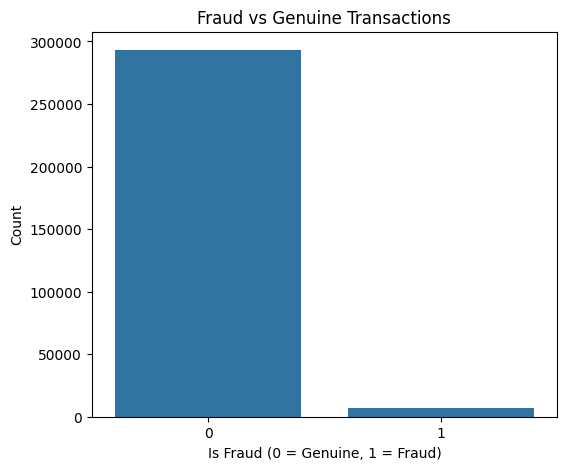

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))
sns.countplot(x='is_fraud', data=df)
plt.title("Fraud vs Genuine Transactions")
plt.xlabel("Is Fraud (0 = Genuine, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

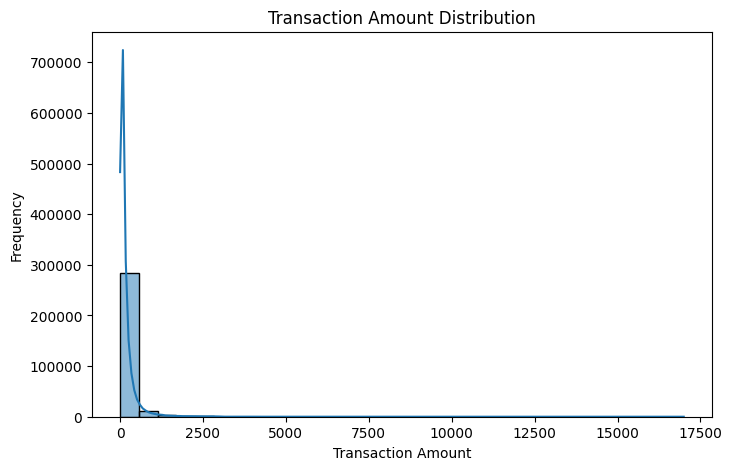

In [23]:
plt.figure(figsize=(8,5))
sns.histplot(df['amount'], bins=30, kde=True)
plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

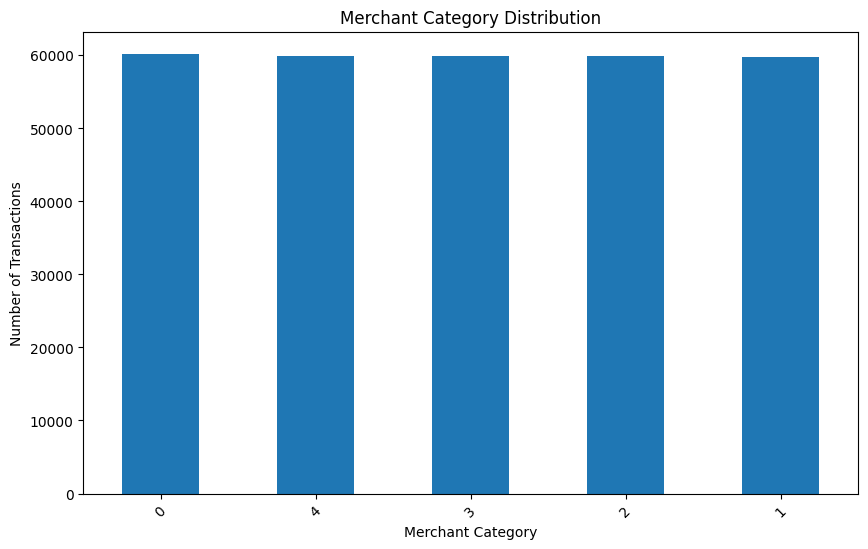

In [24]:
plt.figure(figsize=(10,6))
df['merchant_category'].value_counts().plot(kind='bar')
plt.title("Merchant Category Distribution")
plt.xlabel("Merchant Category")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.show()

In [25]:
joblib.dump('lr', 'FRAUD_DETECTION.joblib')

['FRAUD_DETECTION.joblib']